Scenario:
You are working as a data scientist for a healthcare analytics company. You have been
provided with a dataset containing anonymized patient data. Your task is to clean the data,
visualize it, analyze statistical relationships, and simulate a basic health-related system
using First Order ODEs.


Q1: Outlier Detection and Feature Reduction (2 Marks)
- Use VarianceThreshold to remove constant features (if any).
- Detect and remove outliers from CholesterolLevel using any method of choice.
- Replace any missing values.


In [10]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("patient_data.csv")

In [3]:
df.head()

,PatientID,Gender,Age,CholesterolLevel,BloodPressure,Region,RiskCategory
0,1,Male,37,193.4,129.4,East,High
1,2,Female,45,210.7,107.1,West,Low
2,3,Male,63,244.3,103.9,West,Low
3,4,Male,53,184.5,127.2,West,High
4,5,Male,29,175.7,116.6,South,High


In [4]:
from sklearn.feature_selection import VarianceThreshold

In [11]:
numeric_df=df.select_dtypes(include=[np.number])

In [12]:
var_thres=VarianceThreshold(threshold=0)
var_thres.fit(numeric_df)

VarianceThreshold(threshold=0)

In [16]:
constant=[column for column in numeric_df.columns
         if column not in numeric_df.columns[var_thres.get_support()]]
print(len(constant))

0


In [40]:
for feature in constant:
    print(feature)
    

In [45]:
df1=df.drop(constant)

In [46]:
df1.columns

Index(['PatientID', 'Gender', 'Age', 'CholesterolLevel', 'BloodPressure',
       'Region', 'RiskCategory'],
      dtype='object')

In [47]:
df1.CholesterolLevel.describe()

count    100.000000
mean     201.777000
std       28.236801
min      142.400000
25%      179.425000
50%      202.500000
75%      216.175000
max      281.600000
Name: CholesterolLevel, dtype: float64

In [24]:
import seaborn as sns

<Axes: xlabel='CholesterolLevel', ylabel='Count'>

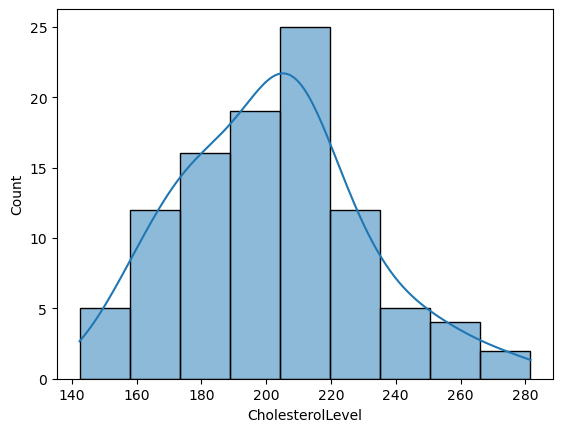

In [48]:
sns.histplot(df1.CholesterolLevel,kde=True)

In [49]:
mean=df1.CholesterolLevel.mean()
mean

201.77699999999996

In [50]:
std=df1.CholesterolLevel.std()

std

28.236801171592376

In [51]:
lower=mean-3*std

In [52]:
upper=mean+3*std

In [57]:
df1_no_outlier=df1[(df1.CholesterolLevel>lower) & (df1.CholesterolLevel<upper)]

In [58]:
df1_no_outlier

,PatientID,Gender,Age,CholesterolLevel,BloodPressure,Region,RiskCategory
0,1,Male,37,193.4,129.4,East,High
1,2,Female,45,210.7,107.1,West,Low
2,3,Male,63,244.3,103.9,West,Low
3,4,Male,53,184.5,127.2,West,High
4,5,Male,29,175.7,116.6,South,High
...,...,...,...,...,...,...,...
95,96,Female,58,224.8,126.9,East,High
96,97,Female,68,200.4,123.0,North,Medium
97,98,Female,71,243.6,111.0,West,Low
98,99,Female,51,192.1,121.0,West,High


In [61]:
df1_no_outlier.fillna(df1_no_outlier.median(numeric_only=True) , inplace=True)

Q2: Data Visualization (2 Marks)
- Generate a box plot comparing BloodPressure between different RiskCategory levels.
- Create a count plot showing the number of patients in each RiskCategory per Region.

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

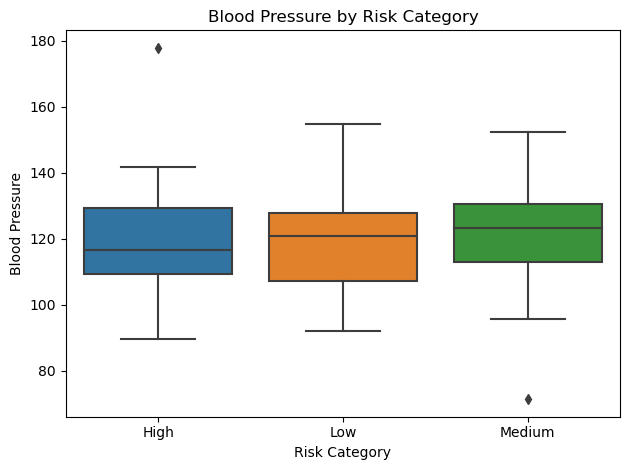

In [65]:
sns.boxplot(x='RiskCategory' , y='BloodPressure',data=df1_no_outlier)
plt.title("Blood Pressure by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Blood Pressure")
plt.tight_layout()
plt.show()

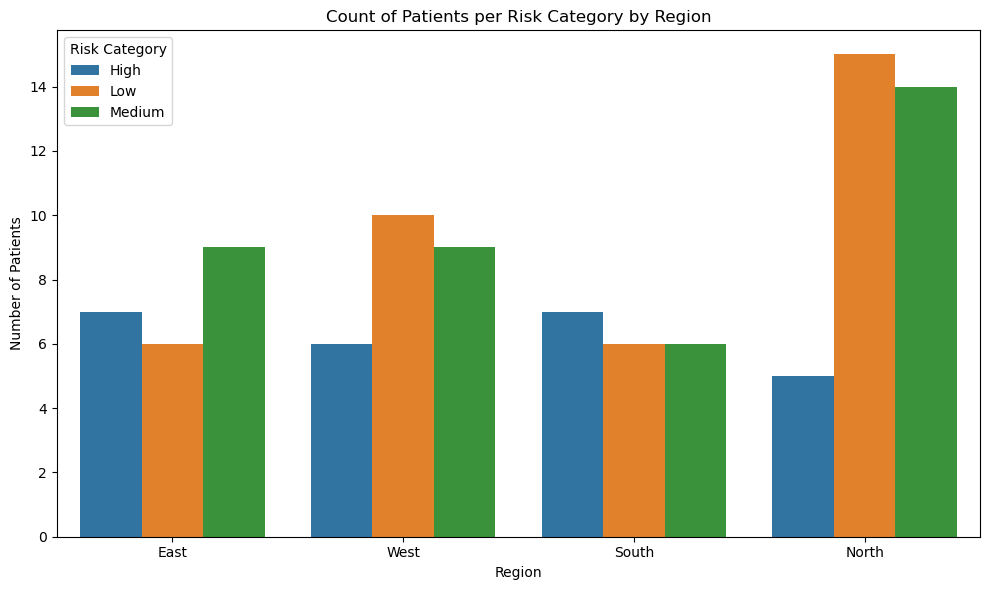

In [66]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Region', hue='RiskCategory', data=df1_no_outlier)
plt.title("Count of Patients per Risk Category by Region")
plt.xlabel("Region")
plt.ylabel("Number of Patients")
plt.legend(title='Risk Category')
plt.tight_layout()
plt.show()


Q3: Statistical Hypothesis Testing (3 Marks)
Perform the following:
- Is the average CholesterolLevel significantly different from 200 mg/dL having a sample
size of 20?
- Is there a significant relationship between Region and RiskCategory?
Include:
- Null and alternative hypotheses
- Test statistic, p-value
- Your interpretation (reject/fail to reject H₀)

In [67]:
from scipy import stats

In [71]:
np.random.seed(42)
sample=df1_no_outlier['CholesterolLevel'].sample(20)

In [74]:
t_test,pvalue=stats.ttest_1samp(sample,popmean=200)

In [75]:
alpha=0.05
if pvalue < alpha:
    print("Reject")
else:
    print("accept")

accept


In [76]:
data_table=pd.crosstab(df1_no_outlier['Region'],df1_no_outlier['RiskCategory'])

In [80]:
chi2,pvalue,expected_values,dof=stats.chi2_contingency(data_table)

In [82]:
if pvalue < 0.05:
    print("Reject")
else:
    print("Accept")

Accept


Q4: Modeling a Health System with ODE (3 Marks)
Model the progression of a patient's medication in the bloodstream.
Equation:
 dC/dt = k(D - C)
Where:
- k = 0.1, D = 100, C(0) = 0
- Solve this ODE for t = 0 to 50 using both odeint and solve_ivp
- Plot the result and explain the difference in output between the two solvers, if any

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp

# Define parameters
k = 0.1
D = 100
C0 = 0  # Initial concentration
t = np.linspace(0, 50, 100)  # Time range

# Define the ODE function
def model(C, t):
    return k * (D - C)

# Solve using odeint
sol1 = odeint(model, C0, t)
C_solve_odeint=sol1.T[0]

# Solve using solve_ivp
def model_ivp(t, C):
    return k * (D - C)

sol = solve_ivp(model_ivp, [0, 50], [C0], t_eval=t)
C_solve_ivp = sol.y[0]


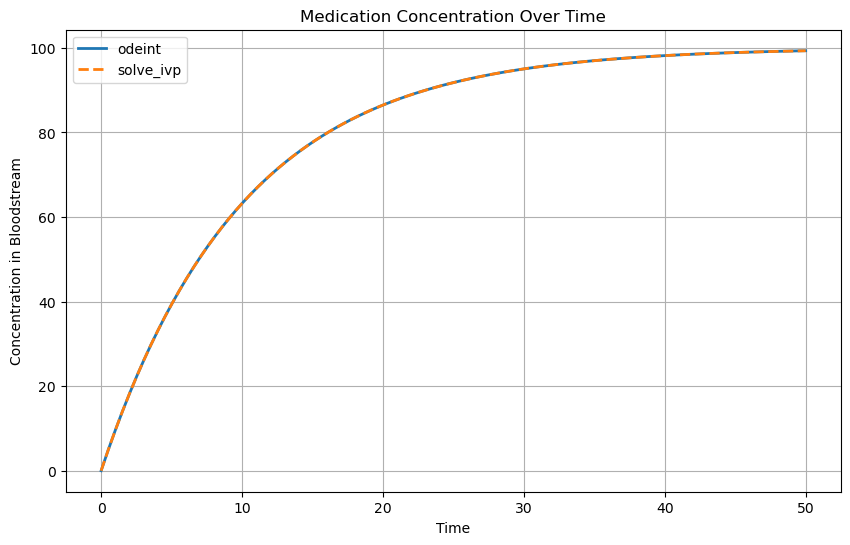

In [87]:
plt.figure(figsize=(10, 6))
plt.plot(t, C_solve_odeint, label='odeint', linewidth=2)
plt.plot(t, C_solve_ivp, '--', label='solve_ivp', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Concentration in Bloodstream')
plt.title('Medication Concentration Over Time')
plt.legend()
plt.grid(True)
plt.show()
